In [1]:
!pip install -q transformers torch scikit-learn imbalanced-learn torchviz seaborn
!pip install -q kaggle

from google.colab import drive
drive.mount('/content/drive')
print('✅ Packages installed and Drive mounted')

Mounted at /content/drive
✅ Packages installed and Drive mounted


In [2]:
import os

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the song lyrics dataset
!kaggle datasets download -d deepshah16/song-lyrics-dataset -p /content/

# Unzip
!unzip -q /content/song-lyrics-dataset.zip -d /content/song_lyrics_raw/
print('✅ Dataset downloaded')

# Check what files are available
!ls /content/song_lyrics_raw/

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/deepshah16/song-lyrics-dataset
License(s): CC0-1.0
100% 19.9M/19.9M [00:00<00:00, 58.2MB/s]

✅ Dataset downloaded
 csv  'json files'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import pandas as pd
import shutil

# Define target artists (only these 3)
TARGET_ARTISTS = ['Ed Sheeran', 'Eminem', 'Justin Bieber']

# Output directory in Google Drive
BASE_DIR = '/content/drive/MyDrive/AI_Project/ML_Agent/dataset'
RECOMMENDED_DIR = os.path.join(BASE_DIR, 'recommended')
NOT_RECOMMENDED_DIR = os.path.join(BASE_DIR, 'not recommended')

os.makedirs(RECOMMENDED_DIR, exist_ok=True)
os.makedirs(NOT_RECOMMENDED_DIR, exist_ok=True)

# The dataset may be CSV files named by artist
# Check the raw data directory
raw_dir = '/content/song_lyrics_raw/csv/' # Corrected path to the CSV subdirectory
all_files = os.listdir(raw_dir)
print('Files in dataset:', all_files)

# Load CSV files for target artists
# The dataset has CSV files named like 'Ed Sheeran.csv', 'Eminem.csv', 'Justin Bieber.csv'
# Adjust the column names based on what's in the CSV

all_lyrics = []

for artist in TARGET_ARTISTS:
    # Try common filename patterns
    possible_names = [
        f'{artist}.csv',
        f'{artist.lower()}.csv',
        f'{artist.replace(" ", "_")}.csv',
        f'{artist.replace(" ", "").lower()}.csv', # e.g., edsheeran.csv
        f'{artist.replace(" ", "")}.csv' # e.g., EdSheeran.csv
    ]
    for fname in possible_names:
        fpath = os.path.join(raw_dir, fname)
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            print(f'Loaded {artist}: {len(df)} songs. Columns: {list(df.columns)}')
            # Common column names in this dataset: 'Lyric', 'lyrics', 'text'
            lyric_col = None
            for col in ['Lyric', 'lyrics', 'text', 'Lyrics']:
                if col in df.columns:
                    lyric_col = col
                    break
            if lyric_col:
                df['artist'] = artist
                df['lyric_text'] = df[lyric_col].astype(str)
                all_lyrics.append(df[['artist', 'lyric_text']])
            break

if all_lyrics:
    combined = pd.concat(all_lyrics, ignore_index=True)
    combined = combined.dropna(subset=['lyric_text'])
    combined = combined[combined['lyric_text'].str.len() > 50]
    print(f'\nTotal songs: {len(combined)}')
    print(combined['artist'].value_counts())
else:
    print('No CSV files found. Check the raw_dir path and filenames.')

Files in dataset: ['CardiB.csv', 'NickiMinaj.csv', 'KatyPerry.csv', 'JustinBieber.csv', 'Maroon5.csv', 'Khalid.csv', 'Rihanna.csv', 'LadyGaga.csv', 'EdSheeran.csv', 'PostMalone.csv', 'TaylorSwift.csv', 'CharliePuth.csv', 'Beyonce.csv', 'ColdPlay.csv', 'BTS.csv', 'ArianaGrande.csv', 'DuaLipa.csv', 'Drake.csv', 'Eminem.csv', 'SelenaGomez.csv', 'BillieEilish.csv']
Loaded Ed Sheeran: 296 songs. Columns: ['Unnamed: 0', 'Artist', 'Title', 'Album', 'Year', 'Date', 'Lyric']
Loaded Eminem: 521 songs. Columns: ['Unnamed: 0', 'Artist', 'Title', 'Album', 'Year', 'Date', 'Lyric']
Loaded Justin Bieber: 348 songs. Columns: ['Unnamed: 0', 'Artist', 'Title', 'Album', 'Year', 'Date', 'Lyric']

Total songs: 1147
artist
Eminem           512
Justin Bieber    344
Ed Sheeran       291
Name: count, dtype: int64


In [ ]:
# Label lyrics: Simple rule-based labeling for training
# Recommended = lyrics with positive/constructive themes
# Not Recommended = lyrics with explicit content

POSITIVE_WORDS = ['love', 'beautiful', 'happy', 'hope', 'dream', 'shine', 'together',
                  'amazing', 'perfect', 'heart', 'smile', 'joy', 'light', 'free', 'rise']
NEGATIVE_WORDS = ['kill', 'die', 'blood', 'hell', 'damn', 'hate', 'war', 'pain',
                  'shoot', 'murder', 'gun', 'knife', 'dead', 'destroy']

def label_lyric(text):
    text_lower = text.lower()
    pos = sum(1 for w in POSITIVE_WORDS if w in text_lower)
    neg = sum(1 for w in NEGATIVE_WORDS if w in text_lower)
    return 'recommended' if pos >= neg else 'not recommended'

combined['label'] = combined['lyric_text'].apply(label_lyric)
print('Label distribution:')
print(combined['label'].value_counts())

# Keep balanced: max 100 per class to speed up training
recommended = combined[combined['label']=='recommended'].head(100)
not_recommended = combined[combined['label']=='not recommended'].head(100)
balanced = pd.concat([recommended, not_recommended]).sample(frac=1, random_state=42)
print(f'\nBalanced dataset size: {len(balanced)}')

# Save to txt files in Drive folders
for i, row in balanced.iterrows():
    folder = RECOMMENDED_DIR if row['label'] == 'recommended' else NOT_RECOMMENDED_DIR
    fname = os.path.join(folder, f'song_{i}.txt')
    with open(fname, 'w', encoding='utf-8') as f:
        f.write(row['lyric_text'])

print(f'\n✅ Saved lyrics to Drive')
print(f'  Recommended: {len(recommended)} files')
print(f'  Not Recommended: {len(not_recommended)} files')

Label distribution:
label
recommended        734
not recommended    413
Name: count, dtype: int64

Balanced dataset size: 200

✅ Saved lyrics to Drive
  Recommended: 100 files
  Not Recommended: 100 files


In [ ]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_cosine_schedule_with_warmup
from torch.optim import AdamW # Corrected import for AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Load data from Drive folders ----
recommended_dir = RECOMMENDED_DIR
not_recommended_dir = NOT_RECOMMENDED_DIR

def load_data_from_directory(directory, label):
    texts, labels = [], []
    for filename in os.listdir(directory):
        if filename.endswith('.txt'):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'r', encoding='utf-8') as f:
                texts.append(f.read())
            labels.append(label)
    return texts, labels

rec_texts, rec_labels = load_data_from_directory(recommended_dir, 'recommended')
not_texts, not_labels = load_data_from_directory(not_recommended_dir, 'not recommended')

texts = rec_texts + not_texts
labels = rec_labels + not_labels
print('Class distribution:', Counter(labels))

Class distribution: Counter({'recommended': 100, 'not recommended': 100})


In [ ]:
# Train/test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# Oversample minority class
oversampler = RandomOverSampler(random_state=42)
train_texts_res, train_labels_res = oversampler.fit_resample(
    np.array(train_texts).reshape(-1, 1), train_labels
)
train_texts_res = train_texts_res.flatten()
print('After oversampling:', Counter(train_labels_res))

# ---- Tokenizer ----
MODEL_NAME = 'facebook/bart-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_data(texts, labels, tokenizer):
    # Truncate lyrics — shorter = faster training
    inputs = tokenizer(
        [f'classify: {t[:300]}' for t in texts],
        truncation=True, padding=True, max_length=256, return_tensors='pt'
    )
    targets = tokenizer(
        labels, truncation=True, padding=True, max_length=10, return_tensors='pt'
    )
    return inputs, targets

train_enc, train_tgt = preprocess_data(train_texts_res, train_labels_res, tokenizer)
test_enc, test_tgt = preprocess_data(test_texts, test_labels, tokenizer)
print('✅ Tokenization complete')

After oversampling: Counter({'not recommended': 80, 'recommended': 80})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenization complete


In [ ]:
class SongLyricsDataset(Dataset):
    def __init__(self, encodings, targets):
        self.encodings = encodings
        self.targets = targets
    def __len__(self):
        return self.targets['input_ids'].shape[0]
    def __getitem__(self, idx):
        item = {key: self.encodings[key][idx] for key in self.encodings}
        item['labels'] = self.targets['input_ids'][idx]
        return item

train_dataset = SongLyricsDataset(train_enc, train_tgt)
test_dataset = SongLyricsDataset(test_enc, test_tgt)

# Use small batch size for memory efficiency
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

# Load model
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f'✅ BART model loaded on {device}')

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

✅ BART model loaded on cpu


In [ ]:
# Training — 3 epochs (small for speed)
NUM_EPOCHS = 3  # Increase to 10 for better accuracy, takes longer

optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def normalize_prediction(text):
    text = text.strip().lower()
    return 'not recommended' if text.startswith('not') else 'recommended'

SAVE_DIR = '/content/drive/MyDrive/AI_Project/ML_Agent/results'
os.makedirs(SAVE_DIR, exist_ok=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        lbl = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=lbl)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Evaluate
    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=10)
            val_preds.extend([normalize_prediction(tokenizer.decode(g, skip_special_tokens=True)) for g in outputs])
            val_true.extend([normalize_prediction(tokenizer.decode(l, skip_special_tokens=True)) for l in batch['labels']])

    acc = accuracy_score(val_true, val_preds)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Val Accuracy: {acc:.4f}')

print('\n=== Final Classification Report ===')
print(classification_report(val_true, val_preds, labels=['not recommended', 'recommended']))

Epoch 1/3 | Loss: 2.5346 | Val Accuracy: 0.5000
Epoch 2/3 | Loss: 0.3505 | Val Accuracy: 0.5500
Epoch 3/3 | Loss: 0.2192 | Val Accuracy: 0.6500

=== Final Classification Report ===
                 precision    recall  f1-score   support

not recommended       0.65      0.65      0.65        20
    recommended       0.65      0.65      0.65        20

       accuracy                           0.65        40
      macro avg       0.65      0.65      0.65        40
   weighted avg       0.65      0.65      0.65        40



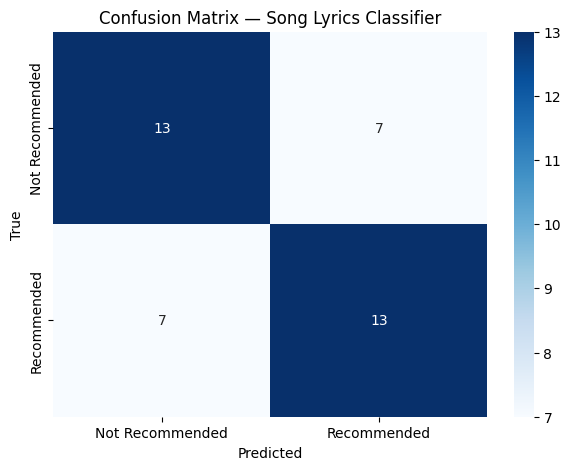


✅ Model saved to: /content/drive/MyDrive/AI_Project/ML_Agent/results/bart_lyrics_model.pt


In [ ]:
# Confusion Matrix
cm = confusion_matrix(val_true, val_preds, labels=['not recommended', 'recommended'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Recommended', 'Recommended'],
            yticklabels=['Not Recommended', 'Recommended'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Song Lyrics Classifier')
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.show()

# Save model
model_save_path = os.path.join(SAVE_DIR, 'bart_lyrics_model.pt')
torch.save(model.state_dict(), model_save_path)
tokenizer.save_pretrained(os.path.join(SAVE_DIR, 'tokenizer'))
print(f'\n✅ Model saved to: {model_save_path}')

In [ ]:
# Load model for inference
loaded_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))
loaded_model.to(device)
loaded_model.eval()

def predict_lyric(lyric_text):
    inputs = tokenizer(
        f'classify: {lyric_text[:300]}',
        return_tensors='pt', truncation=True, max_length=256
    ).to(device)
    with torch.no_grad():
        output = loaded_model.generate(**inputs, max_length=10)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    return normalize_prediction(decoded)

# Test
sample = 'I found a love for me. Darling just dive right in, follow my lead.'
result = predict_lyric(sample)
print(f'Lyric: "{sample[:60]}..."')
print(f'Classification: {result}')

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Lyric: "I found a love for me. Darling just dive right in, follow my..."
Classification: not recommended
